In [ ]:
# 데이터 로딩 이전 단계(환경 확인)
import os

os.listdir('./') 
# './' = 현재 작업 경로를 뜻함
# 이 안에 들어 있는 파일/폴더 이름을 list 형태로 반환

['2025.08.11 수업.ipynb',
 'Breast Cancer 데이터 분석 복습.ipynb',
 'building_info.csv',
 'data.ipynb',
 'gemini.ipynb',
 'Heart Failure 8월 4일 수업.ipynb',
 'sample_submission.csv',
 'submission.csv',
 'submission_aligned.csv',
 'submission_day02.csv',
 'submission_day03.csv',
 'submission_day03_hybrid.csv',
 'submission_day03_plus.csv',
 'submission_match_day02.csv',
 'submission_xgb_ensemble.csv',
 'test.csv',
 'train.csv',
 '복습.ipynb',
 '전력사용량 예측 복습.ipynb',
 '전력소비량 예측.ipynb']

In [ ]:
# ================ #
# 1. 라이브러리 로드
# ================ #
import pandas as pd 
import numpy as np
import warnings 
warnings.filterwarnings('ignore') # 코드 실행 시 발생하는 경고 메시지 무시(FutureWarning 같은 것)

from sklearn.model_selection import KFold # 사이킷런의 교차검증 기법 중 하나, 데이터를 여러 조각으로 나눠 학습/검증에 사용
from sklearn.metrics import mean_absolute_error # 모델 평가 지표. MAE(평균 절대 오차) 를 계산할 때 사용
from xgboost import XGBRegressor # 이번 분석의 핵심 모델인 XGBoost 회귀기를 불러오는 부분

# ================ #
# 2. 데이터 로드
# ================ #
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")
submission = pd.read_csv("sample_submission.csv")

print(train_df.shape, test_df.shape, submission.shape)
train_df.head()

(204000, 10) (16800, 7) (16800, 2)


,num_date_time,건물번호,일시,기온(°C),강수량(mm),풍속(m/s),습도(%),일조(hr),일사(MJ/m2),전력소비량(kWh)
0,1_20240601 00,1,20240601 00,18.3,0.0,2.6,82.0,0.0,0.0,5794.80
1,1_20240601 01,1,20240601 01,18.3,0.0,2.7,82.0,0.0,0.0,5591.85
2,1_20240601 02,1,20240601 02,18.1,0.0,2.6,80.0,0.0,0.0,5338.17
3,1_20240601 03,1,20240601 03,18.0,0.0,2.6,81.0,0.0,0.0,4554.42
4,1_20240601 04,1,20240601 04,17.8,0.0,1.3,81.0,0.0,0.0,3602.25


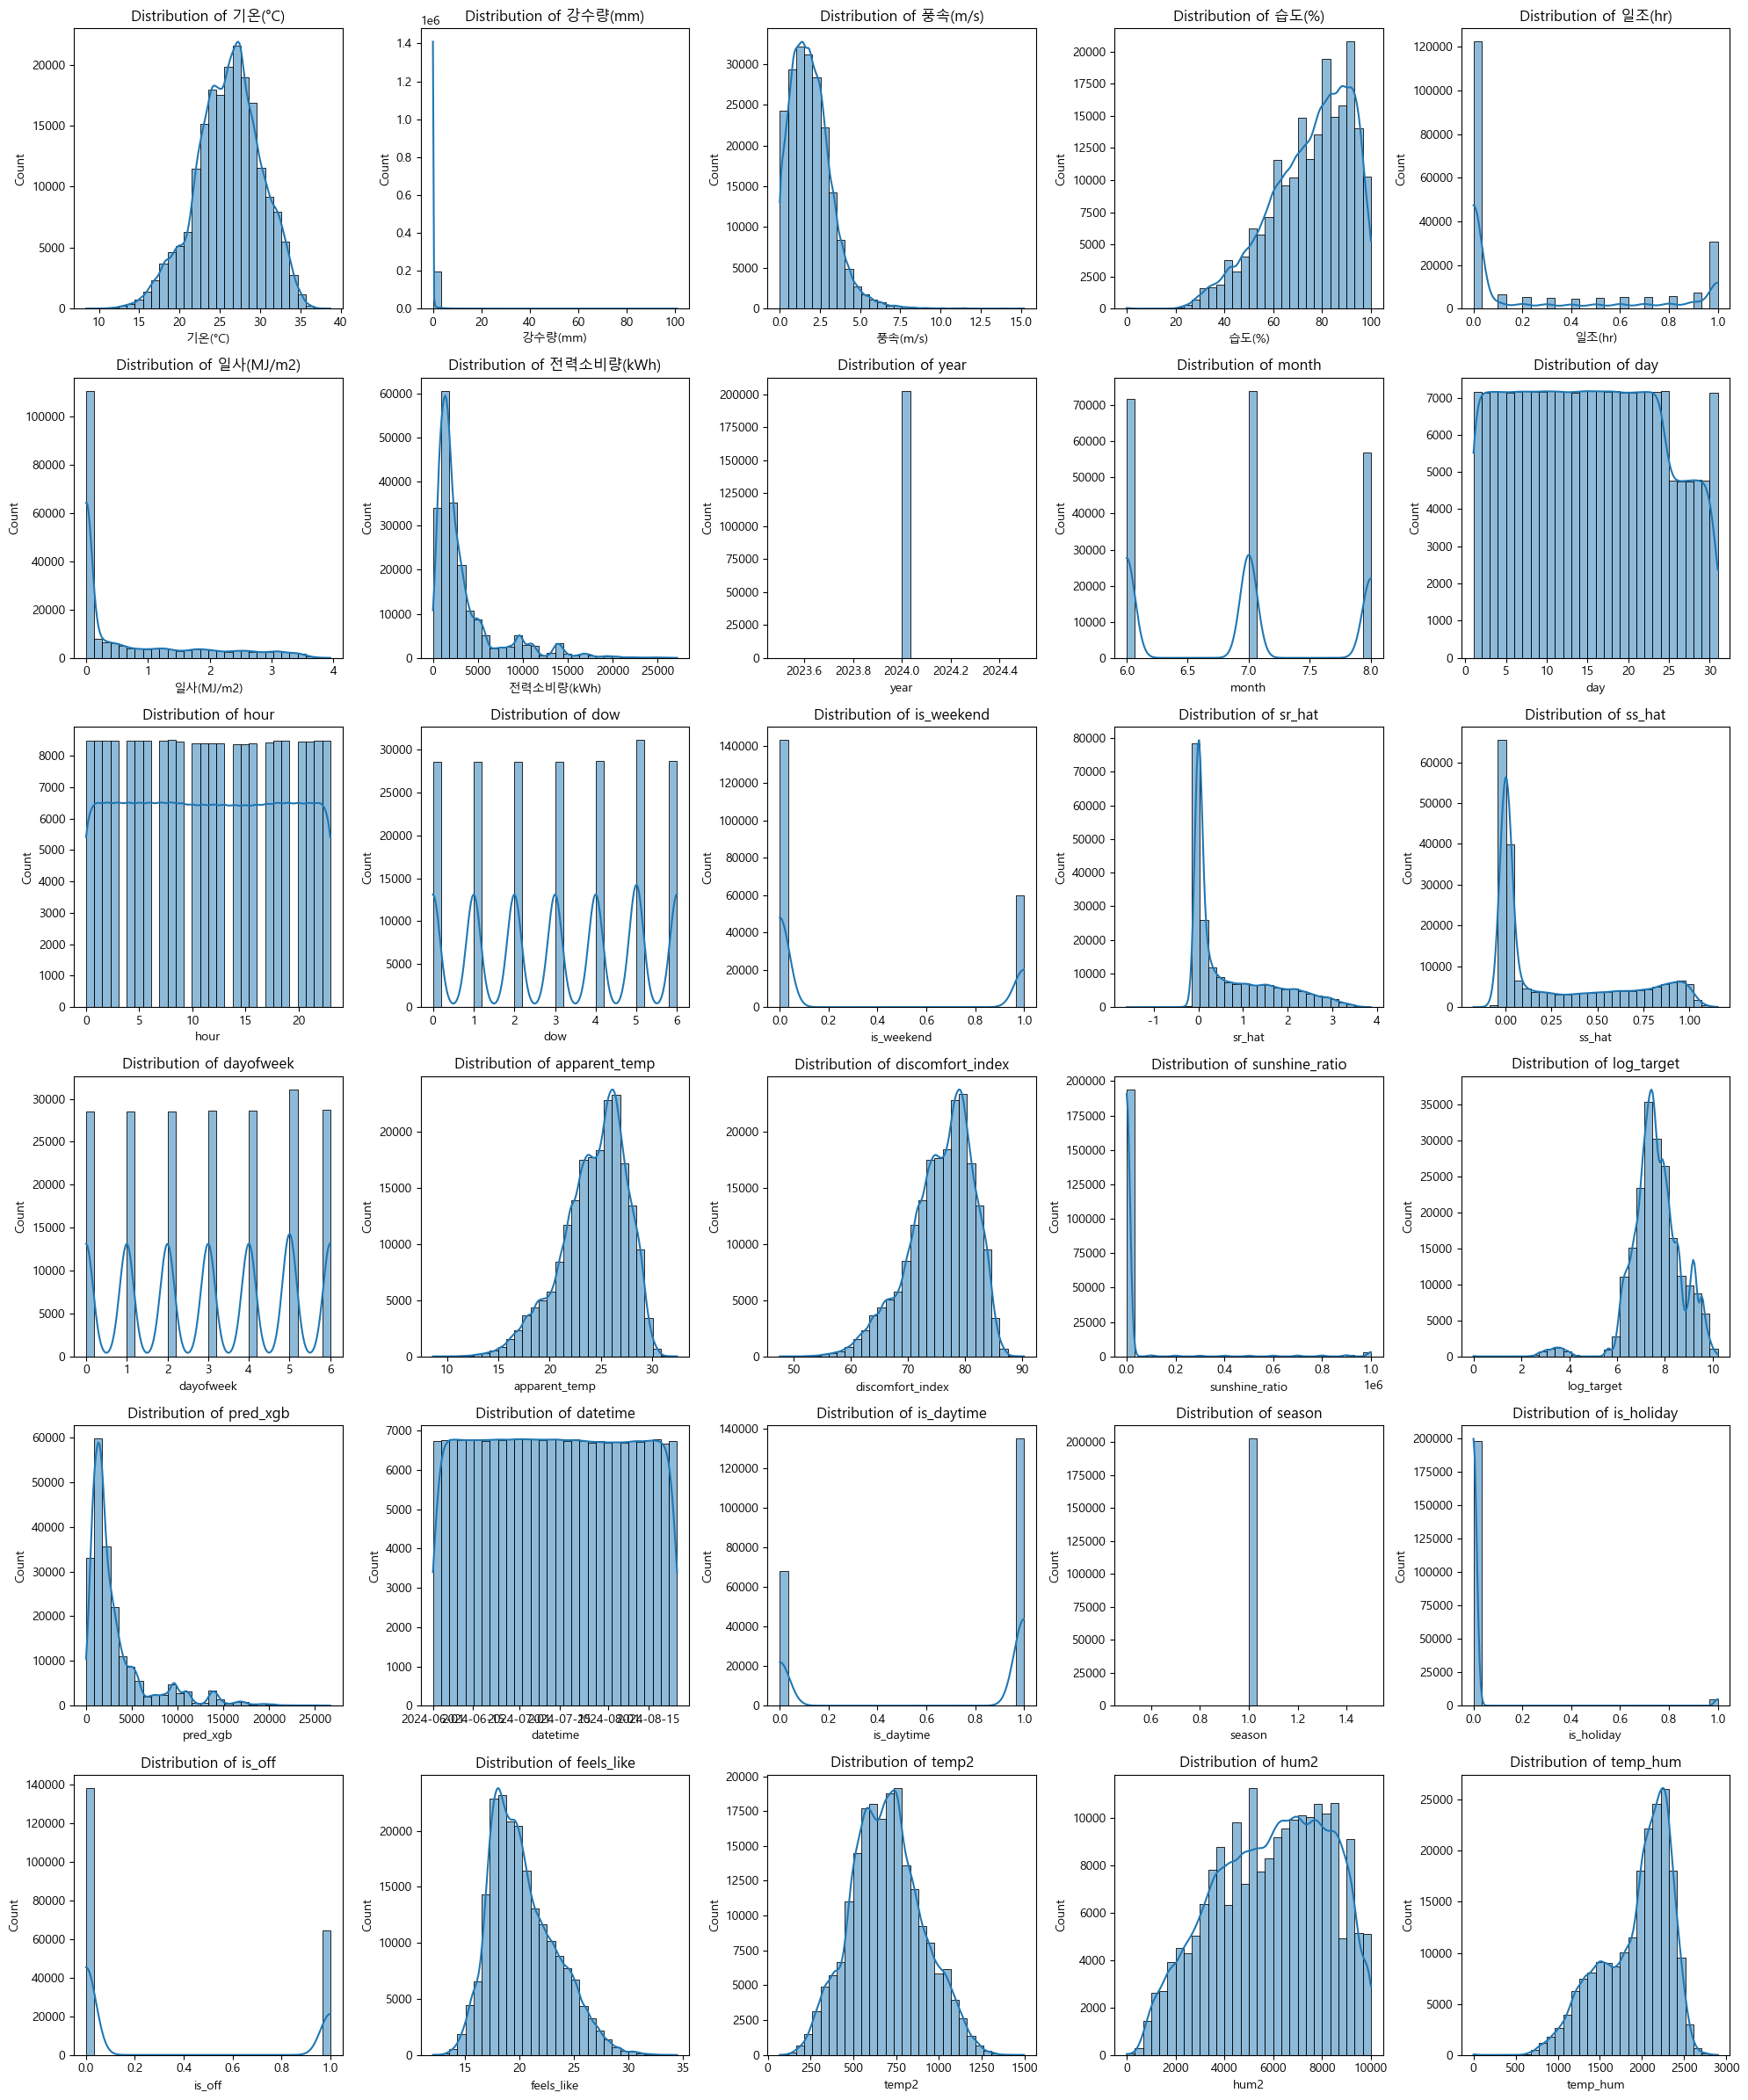

In [ ]:
# 3. EDA
# 전체 분포 확인
import math
import matplotlib.pyplot as plt
import seaborn as sns

# ID, 시간, 범주형 제외
hist_df = train_df.drop(columns=['num_date_time','date','건물번호','건물유형'], errors='ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

n_features = list(hist_df.columns)
n_cols = 5
n_rows = math.ceil(len(n_features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
ax = axes.flatten()

for i, col in enumerate(hist_df.columns):
    sns.histplot(hist_df[col].dropna(), bins=30, kde=True, ax=ax[i])
    ax[i].set_title(f'Distribution of {col}', fontsize=12)

for i in range(len(n_features), len(ax)):
    ax[i].axis('off')

plt.tight_layout()
plt.show()


# 내가 확인해야 하는 것 #
# 1. 분포가 정규/대칭형인지 vs 치우쳐 있는지
# 기온 : 종 모양의 정규 분포
# 습도 : 약간 오른쪽 꼬리가 긴 분포지만 문제 없음
# 풍속 : 0근처에 몰려 있고 긴 꼬리가 있음 -> log 변환 시 안정화 가능
# 강수량 : 대부분 0에 몰려 있고 일부 극단값 -> log1p 변환이 효과적
# 일조, 일사 : 0이 많고 오른쪽 긴 꼬리 : log1p 변환 고려 가능


# log(x) 는 x>0 일때만 정의, 0값이 들어오면 에러
# 일사, 일조, 강수량 = 0값이 굉장히 많음(0 : 비 안 오는 날, 해 안뜬 밤)
# 그래서 log(1+x) = log1p(x) 를 써서 0을 안전하게 변환 시키는 것

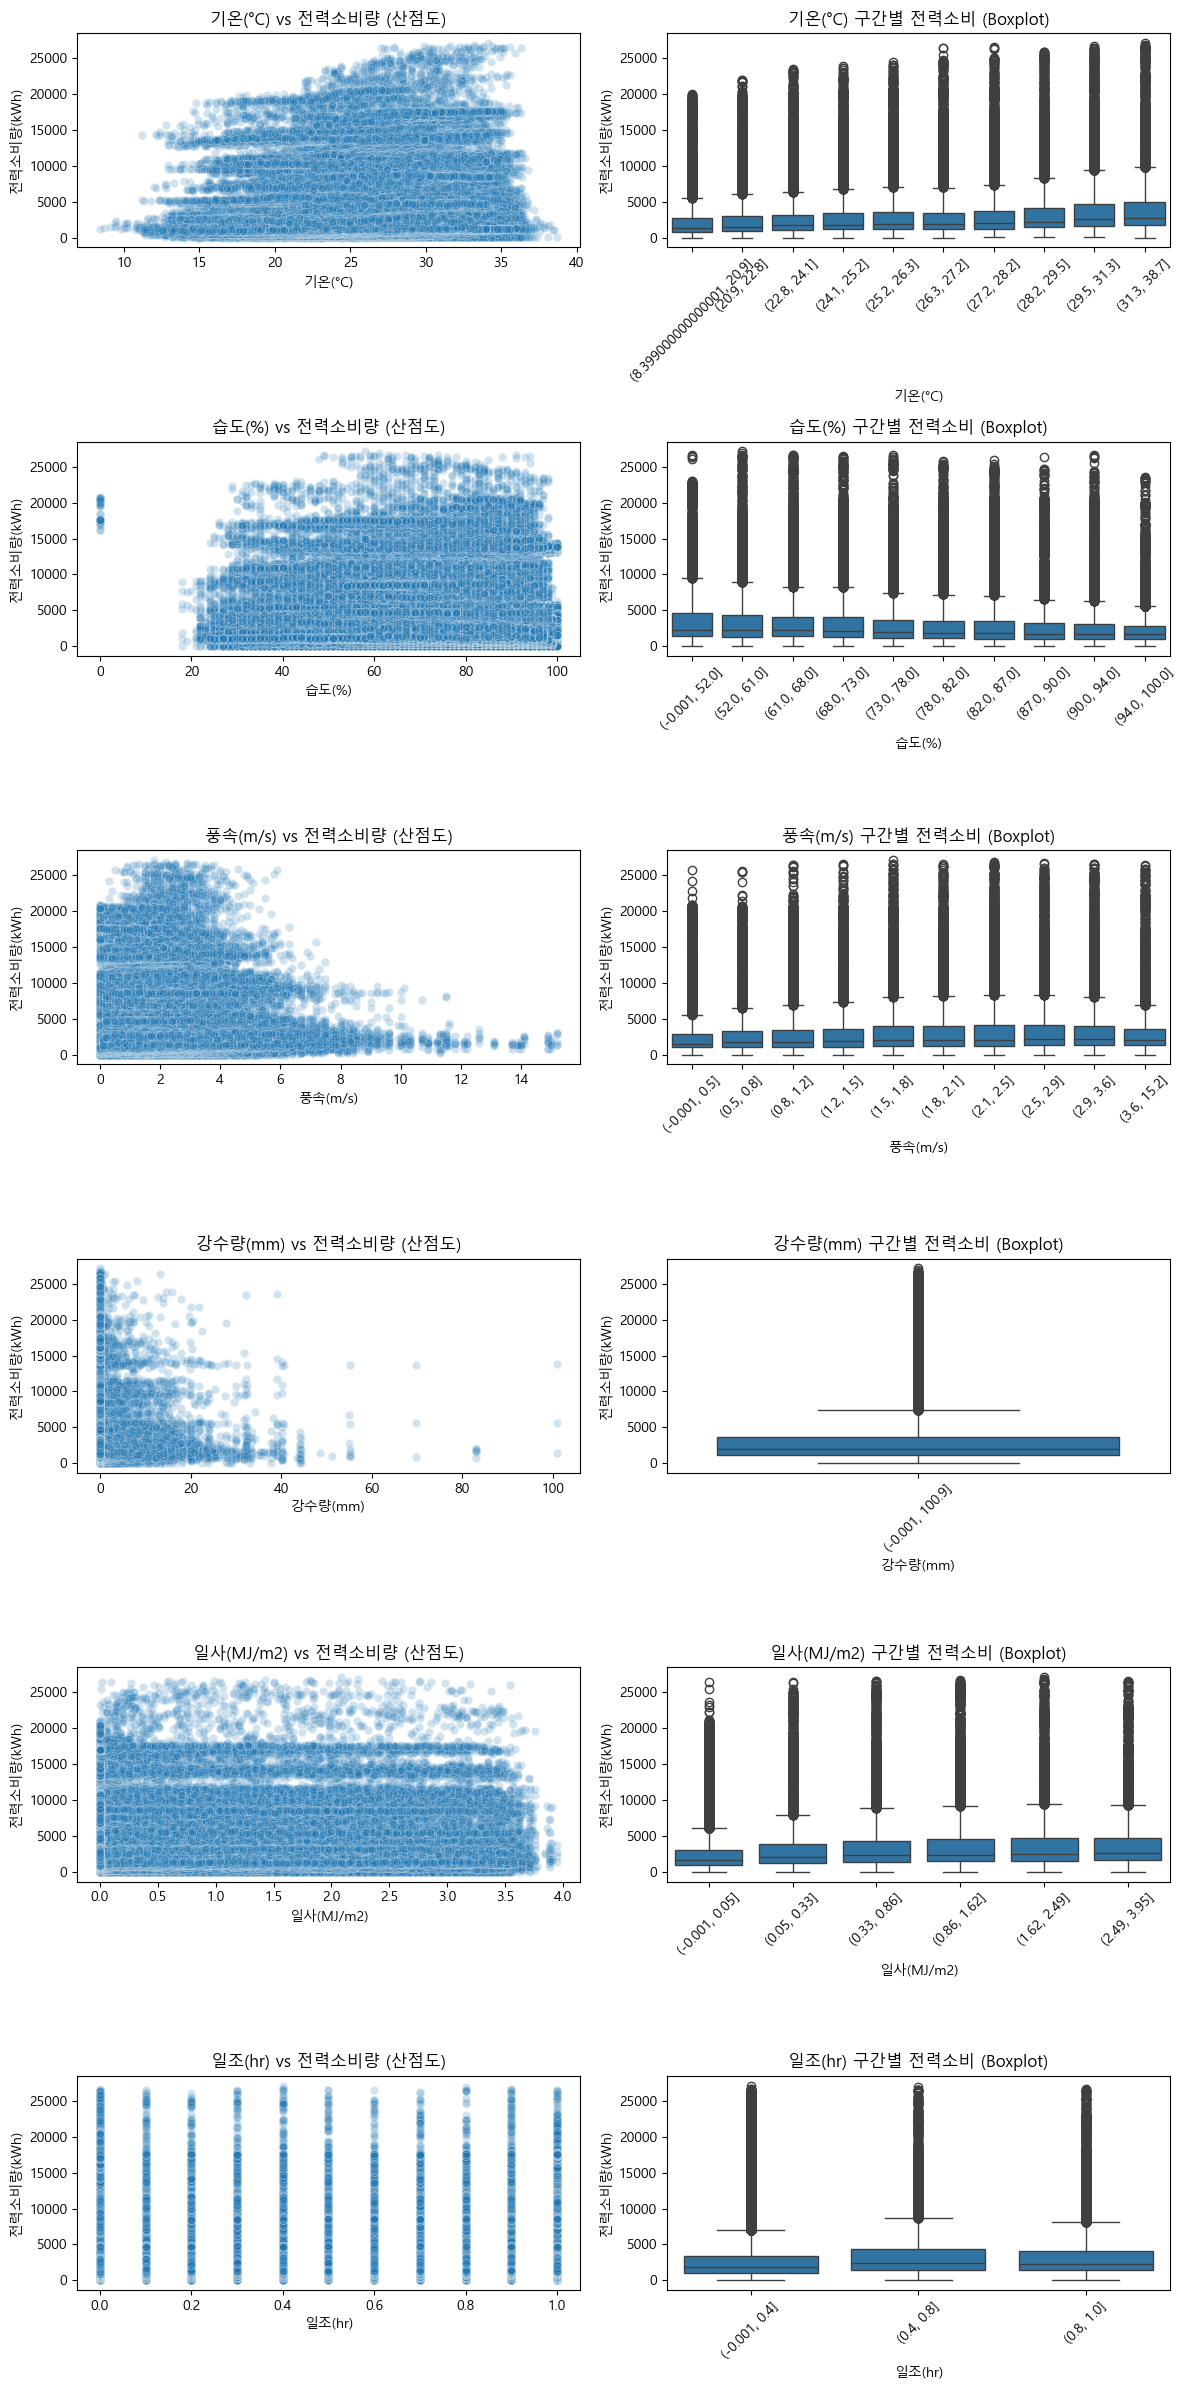

In [ ]:
# 기상 변수 vs 전력 소비량 

import matplotlib.pyplot as plt
import seaborn as sns

# 비교할 후보 변수들
features = ["기온(°C)", "습도(%)", "풍속(m/s)", "강수량(mm)", "일사(MJ/m2)", "일조(hr)"]

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(len(features), 2, figsize=(12, len(features)*4))

for i, col in enumerate(features):
    # 산점도
    sns.scatterplot(
        x=train_df[col],
        y=train_df["전력소비량(kWh)"],
        alpha=0.2,
        ax=axes[i,0]
    )
    axes[i,0].set_title(f"{col} vs 전력소비량 (산점도)")

    # Boxplot (구간별 분포 확인)
    sns.boxplot(
        x=pd.qcut(train_df[col], q=10, duplicates="drop"),
        y=train_df["전력소비량(kWh)"],
        ax=axes[i,1]
    )
    axes[i,1].set_title(f"{col} 구간별 전력소비 (Boxplot)")
    axes[i,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


# 기온 : 산점도에서 우상향 경향 보임. boxplot 에서도 구간별 중앙값이 확실히 상승
# 습도 : 산점도는 퍼져 있지만 boxplot 보면 높은 습도 구간에서 소비량이 약간 높은 편 -> 보조 변수 ?
# 풍속/강수량 : 산점도는 거의 영향 없음, boxplot 도 중앙값 차이가 작음 -> 영향 적음
# 일사/일조 : 산점도는 점이 흩어져 있고, boxplot 도 차이 적음 -> 단독으론 영향 적지만 다른 변수와 상호작용 가능성 있음

# -> 일사/일조, feature importance 확인 필요

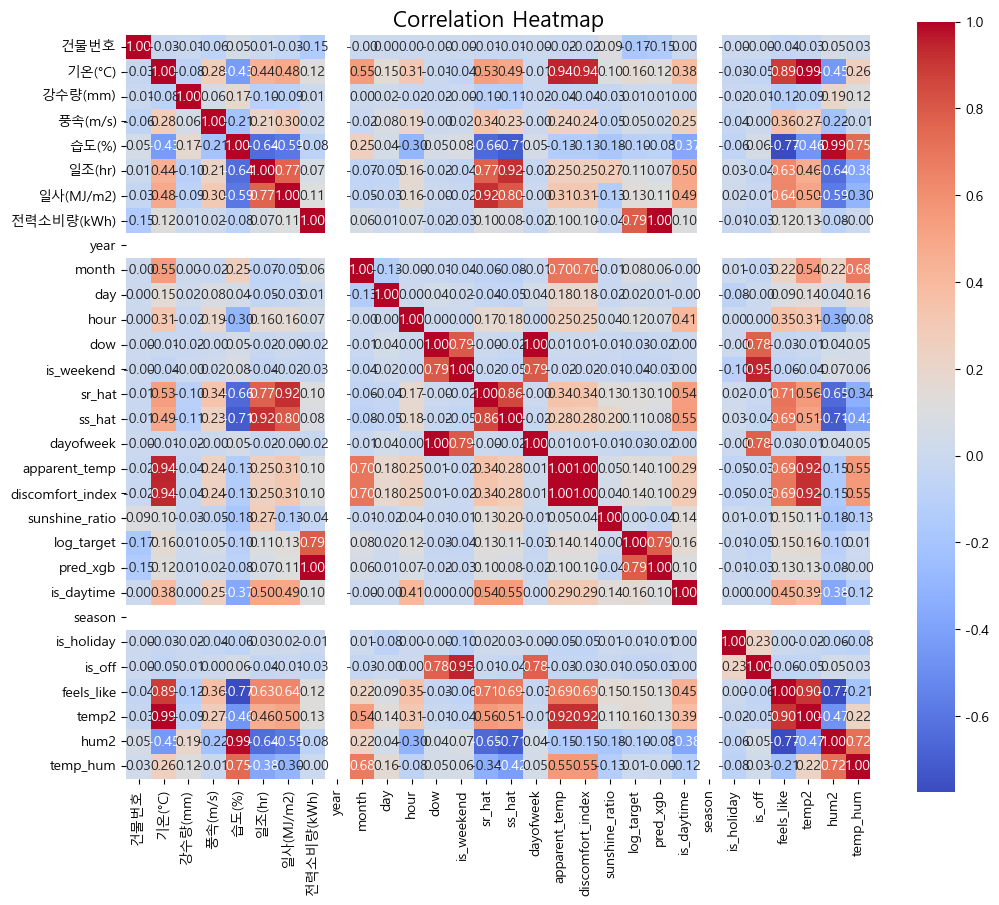

✅ 타깃과의 상관관계 순위:
전력소비량(kWh)          1.000000
pred_xgb            0.998664
log_target          0.789888
temp2               0.125682
feels_like          0.124838
기온(°C)              0.123587
일사(MJ/m2)           0.108787
apparent_temp       0.104864
discomfort_index    0.104753
is_daytime          0.103566
sr_hat              0.101609
ss_hat              0.083741
hour                0.069355
일조(hr)              0.066084
month               0.064948
풍속(m/s)             0.021143
day                 0.013156
강수량(mm)             0.009559
temp_hum           -0.002207
is_holiday         -0.008435
dayofweek          -0.024626
dow                -0.024626
is_weekend         -0.032671
is_off             -0.034727
sunshine_ratio     -0.035116
습도(%)              -0.083227
hum2               -0.083352
건물번호               -0.147792
year                     NaN
season                   NaN
Name: 전력소비량(kWh), dtype: float64


In [136]:
import matplotlib.pyplot as plt
import seaborn as sns

# === 상관관계 계산 (train 데이터 기준) ===
corr = train_df.corr(numeric_only=True)

# === 히트맵 그리기 ===
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr, 
    annot=True, fmt=".2f", cmap="coolwarm", 
    cbar=True, square=True
)
plt.title("Correlation Heatmap", fontsize=16)
plt.show()

# 타깃과의 상관관계만 따로 보기
target_corr = corr["전력소비량(kWh)"].sort_values(ascending=False)
print("✅ 타깃과의 상관관계 순위:")
print(target_corr)


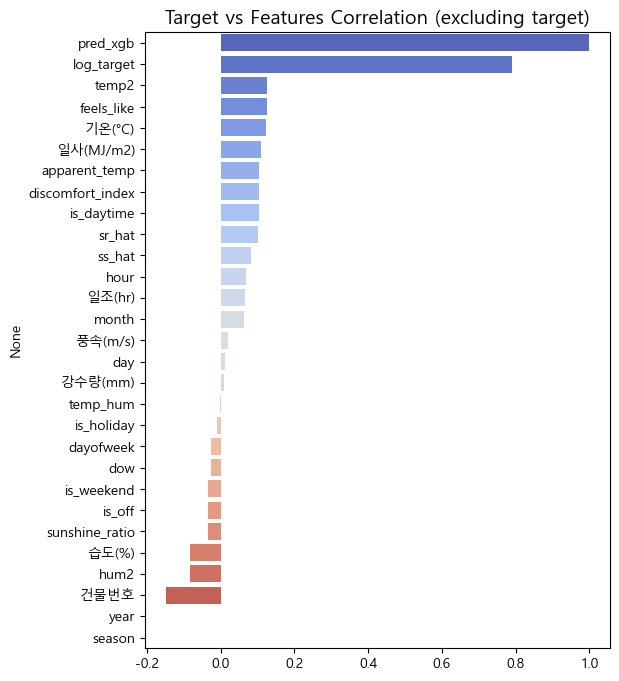

In [ ]:
# 전력소비량과 상관이 큰 변수 확인

target_corr = corr["전력소비량(kWh)"].drop("전력소비량(kWh)").sort_values(ascending=False)

plt.figure(figsize=(6,8))
sns.barplot(
    x=target_corr.values, 
    y=target_corr.index, 
    palette="coolwarm"
)
plt.title("Target vs Features Correlation (excluding target)", fontsize=14)
plt.show()

# pred_xgb, log_target : 파생/보조모델 결과
# 실제 가치 있는 건 
# : temp2(기온의 제곱항 : 비선형 관계를 잡기 위해 만든 파생 변수)
# : feels_like(체감온도 : 기온+습도+풍속 조합)(사람이 실제로 느끼는 덥고 추움이 전력소비에 직접적인 영향을 줌)
# : 기온, 일사

# temp2 제곱항을 쓰는 이유 ?
# ->전력 소비량 = a X 기온 + b 이런 식이라면 기온이 오를 수록 전력 소비가 직선으로 증가해야 함
# 실제 : 추울 때 난방때문에 전력 상승, 적당히 선선할 때 냉난방 둘 다 안써서 전력 감소, 더울 때 냉방 때문에 전력 상승
# 기온과 전력 소비 : U자형 곡선

# 제곱항이 하는 역할
# 기온2 을 같이 써서 포물선 곡선 표현 가능

In [138]:
import numpy as np

# 1) 다중공선성 확인에서 제외할 컬럼(있을 때만 자동 제외)
exclude = [c for c in ['전력소비량(kWh)', 'log_target', 'pred_xgb'] if c in corr.columns]
corr_use = corr.drop(index=exclude, columns=exclude, errors='ignore')

# 2) 상삼각만 보고(|r| >= 0.90), 자기 자신 제외
thr = 0.90
cols = corr_use.columns
pairs = []
for i in range(len(cols)):
    for j in range(i+1, len(cols)):   # 상삼각만
        r = corr_use.iloc[i, j]
        if abs(r) >= thr:
            pairs.append((cols[i], cols[j], float(r)))

# 3) 큰 순으로 정렬해서 보기
pairs_sorted = sorted(pairs, key=lambda x: abs(x[2]), reverse=True)
print(f"강한 상관 피처쌍 (|r| ≥ {thr:.2f}, 상위 30개):")
for a, b, r in pairs_sorted[:30]:
    print(f"{a:>18}  ~  {b:<18} : r = {r:.3f}")


강한 상관 피처쌍 (|r| ≥ 0.90, 상위 30개):
               dow  ~  dayofweek          : r = 1.000
     apparent_temp  ~  discomfort_index   : r = 1.000
            기온(°C)  ~  temp2              : r = 0.994
             습도(%)  ~  hum2               : r = 0.990
        is_weekend  ~  is_off             : r = 0.946
            기온(°C)  ~  apparent_temp      : r = 0.945
            기온(°C)  ~  discomfort_index   : r = 0.944
     apparent_temp  ~  temp2              : r = 0.924
  discomfort_index  ~  temp2              : r = 0.923
            일조(hr)  ~  ss_hat             : r = 0.923
         일사(MJ/m2)  ~  sr_hat             : r = 0.919
        feels_like  ~  temp2              : r = 0.903


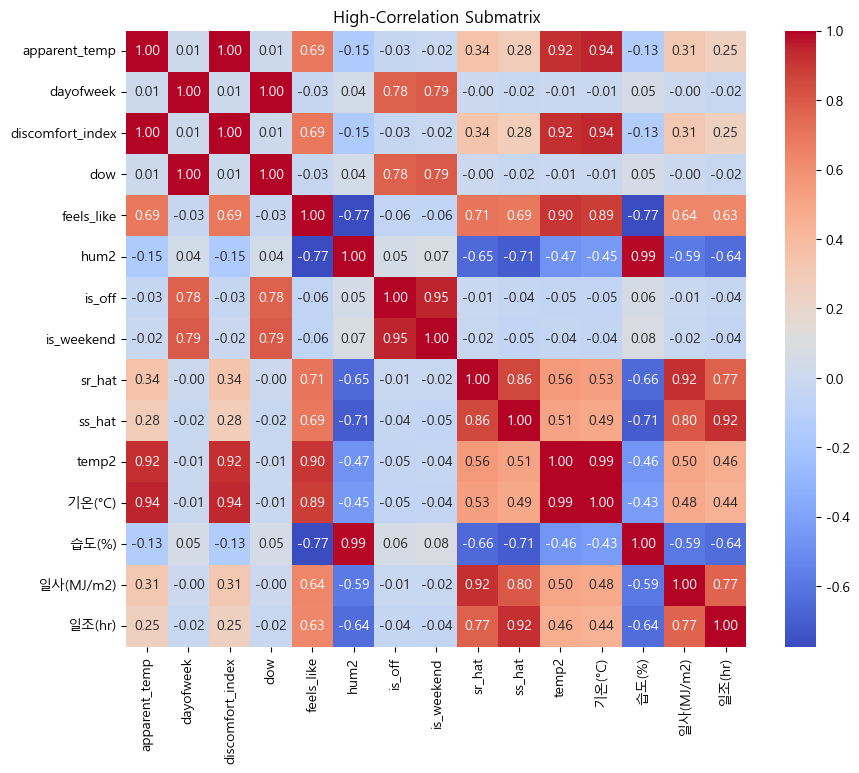

In [139]:
# 강한 상관 피처에 등장한 컬럼들만 추리기
strong_cols = sorted({x for ab in pairs_sorted for x in ab[:2]})
if strong_cols:
    import seaborn as sns
    import matplotlib.pyplot as plt
    plt.figure(figsize=(min(10, 0.6*len(strong_cols)+3), min(8, 0.6*len(strong_cols)+3)))
    sns.heatmap(corr_use.loc[strong_cols, strong_cols], annot=True, fmt=".2f", cmap="coolwarm")
    plt.title("High-Correlation Submatrix")
    plt.show()
else:
    print("✅ |r| ≥ threshold 조건을 만족하는 피처쌍이 없습니다.")


In [ ]:
# 4. 데이터 전처리 
# === XGB가 싫어하는 object 컬럼 정리 ===
import pandas as pd
import numpy as np

def prep_datetime_and_types(df): # 데이터프레임에서 XGBoost 가 학습 가능한 형태로 변환
    # 1) 공통 'date' 컬럼 만들기 (데이터셋에 맞춰 후보명을 확인)
    for cand in ['date', '일시', 'datetime', 'time']:
        if cand in df.columns:
            df['date'] = pd.to_datetime(df[cand], errors='coerce')
            break

    # 2) 날짜 파생변수 생성 (숫자형)
    if 'date' in df.columns:
        df['year'] = df['date'].dt.year
        df['month'] = df['date'].dt.month
        df['day'] = df['date'].dt.day
        # 시(hour) 컬럼이 없다면 0으로 처리 (데이터에 시 정보가 없을 수 있음)
        try:
            df['hour'] = df['date'].dt.hour
        except Exception:
            df['hour'] = 0
        df['dow'] = df['date'].dt.dayofweek
        df['is_weekend'] = (df['dow'] >= 5).astype(int)

    # 3) 원본 문자열 datetime 컬럼 제거 (에러 원인이었던 것들)
    for col in ['일시', 'num_date_time']:
        if col in df.columns:
            df.drop(columns=[col], inplace=True)

    # 4) 남은 object 컬럼 처리:
    #    - XGBoost는 숫자형/boolean/category만 허용.
    #    - 간단하게: 남아있는 object는 범주형 인코딩(공통 factorize) 또는 제거 중 선택.
    # 여기서는 안전하게 공통 factorize로 숫자화합니다.
    obj_cols = df.select_dtypes(include=['object']).columns.tolist()
    # ID성 텍스트가 있다면 위에서 date로 치환했으므로 보통 없음.
    # 필요시 특정 컬럼은 제외 가능(예: 텍스트 설명이 완전 무의미하면 드랍해도 됨)
    # factorize는 결측 포함 대비를 위해 fillna('NA') 한 뒤 진행
    # ex) 학고 -> 0, 회사 -> 1, 병원 -> 2
    for c in obj_cols:
        df[c] = df[c].fillna('NA')
        df[c] = pd.factorize(df[c])[0].astype(np.int64)

    return df

# 두 데이터프레임에 동일 전처리
train_df = prep_datetime_and_types(train_df)
test_df  = prep_datetime_and_types(test_df)

# (선택) 주요 결측치 간단 보완(중앙값으로 보완)
for df in [train_df, test_df]:
    for col in ['일사(MJ/m2)', '일조(hr)']:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].median())


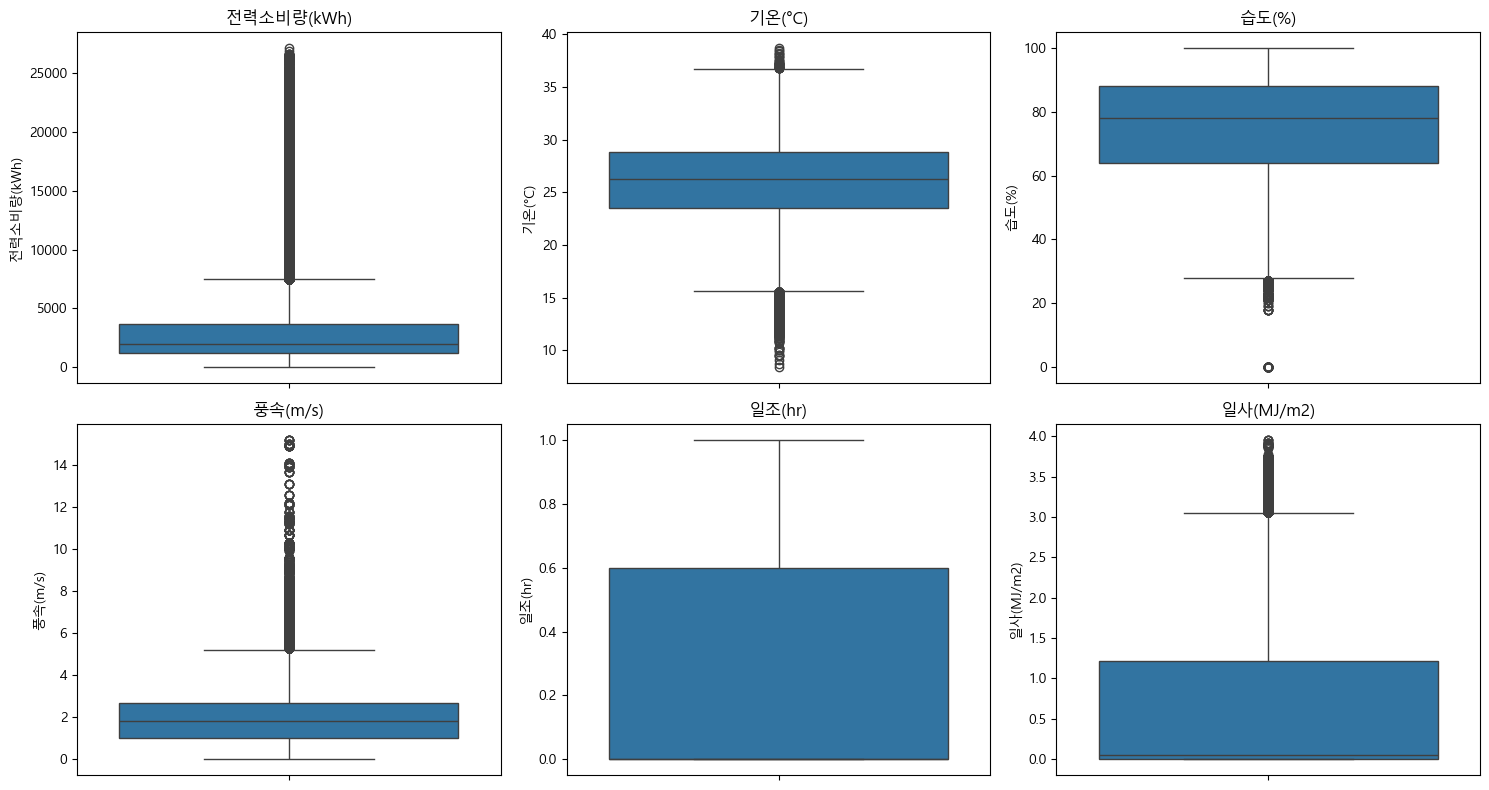

In [ ]:
# 이상치 시각화

import matplotlib.pyplot as plt
import seaborn as sns

# 시각화할 변수 6개 선택
cols_to_plot = [
    "전력소비량(kWh)", "기온(°C)", "습도(%)",
    "풍속(m/s)", "일조(hr)", "일사(MJ/m2)"
]

plt.figure(figsize=(15, 8))

for i, col in enumerate(cols_to_plot, 1):
    plt.subplot(2, 3, i)  # 2행 3열 서브플롯
    sns.boxplot(y=train_df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

# 전력소비량 : 극단적으로 높은 소비 구간. 현실적으로 특수 상황(이상치 or 특정 대형 이벤트)일 수 있음. 모델 학습에 영향 크므로 제거 또는 조정
# 기온 : 40도 이상은 국내 환경에서 드물고, -30 이하도 비현실적이므로 이상치로 간주
# 습도 : 0% 자연 상태에서 불가능, 100% 는 가능하지만 극단값이 많으면 의심 필요
# 풍속 : 15이상이면 태풍수준이라 드문 값, 데이터상 너무 많으면 센서 오류 가능
# 일조 : 깔끔
# 일사 : 일부 극단적으로 높은 값. 태양 복사량이 일정 물리적 한계를 넘어가면 이상치로 처리하는게 적절

In [ ]:
# ============================= #
# 4. 이상치 처리
# ============================= #

# 1) 물리적으로 불가능한 기상값 drop
train_df = train_df[train_df['기온(°C)'].between(-30, 45)] #-30~45 사이 값만 남김
train_df = train_df[train_df['습도(%)'].between(0, 100)] # 0~100% 만 유효
train_df = train_df[train_df['전력소비량(kWh)'] >= 0]  # 음수값 제거 

# 물리적 불가능값 제거한 것

# 2) 건물별 전력 소비 이상치 drop (IQR 방식)
def drop_outliers_iqr(df, target='전력소비량(kWh)', group='건물번호'):
    clean_df = []
    for b_id, g in df.groupby(group): # 데이터프레임을 건물번호별로 묶음
        q1 = g[target].quantile(0.25) 
        q3 = g[target].quantile(0.75)
        iqr = q3 - q1 # 사분위 범위 : 데이터가 대부분을 분포하는 중간 범위
        lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr # 하한선, 상한선을 벗어나면 극단값 간주
        g = g[(g[target] >= lower) & (g[target] <= upper)] # 이상치를 제외한 데이터만 남김
        clean_df.append(g) # 건물별로 클린 데이터 저장
    return pd.concat(clean_df) # 건물별로 처리한 결과를 다시 합쳐 전체 데이터 프레임 반환

train_df = drop_outliers_iqr(train_df) # train_df 갈아끼우기

print("✅ 이상치 처리 완료:", train_df.shape)

# 3) 스케일링 (선택)
# log1p 변환 후, 모델 예측 끝나고 expm1으로 되돌림
train_df['log_target'] = np.log1p(train_df['전력소비량(kWh)'])

# 왜냐? 전력소비량 분포가 치우쳐 있으니 log1p로 변환. 

✅ 이상치 처리 완료: (202043, 32)


In [ ]:
# ===============================================
# 5. 파생변수 생성 Feature engineering 
# ===============================================
import pandas as pd

# 2024 한국 공휴일 (대체공휴일 포함)
HOLIDAYS_2024 = pd.to_datetime([
    "2024-01-01", "2024-02-09", "2024-02-10", "2024-02-11", "2024-02-12",
    "2024-03-01", "2024-04-10", "2024-05-05", "2024-05-06", "2024-05-15",
    "2024-06-06", "2024-08-15", "2024-09-16", "2024-09-17", "2024-09-18",
    "2024-10-03", "2024-10-09", "2024-12-25"
])

def add_time_features(df, date_col="date"):
    df = df.copy()
    df["datetime"] = pd.to_datetime(df[date_col], errors="coerce") # 문자열로 되어 있던 날짜를 datetime 으로 변환
    # errors = 'coerce' : 변환 불가능한 값은 NaT(Nat a Time) 으로 처리 
    
    dt = df["datetime"]
    df["year"]       = dt.dt.year
    df["month"]      = dt.dt.month
    df["day"]        = dt.dt.day
    df["hour"]       = dt.dt.hour
    df["dayofweek"]  = dt.dt.dayofweek  # 0=월 ~ 6=일

    # 주간/야간
    df["is_daytime"] = ((df["hour"] >= 6) & (df["hour"] <= 21)).astype(int)
    # 아침 6 ~ 밤 9시 사이면 1, 그 외는 0
    
    # 계절
    def _season(m):
        if m in (3,4,5):   return 0
        if m in (6,7,8):   return 1
        if m in (9,10,11): return 2
        return 3
    df["season"] = df["month"].map(_season).astype(int)
    # 기온, 일사량 등 계절별 패턴 차이 크기 때문에 중요

    # 휴일/주말/쉬는날
    dates_only = dt.dt.normalize() # hour 이하를 없애고 날짜만 비교 가능하게 만듦
    holiday_dates = pd.to_datetime(HOLIDAYS_2024).normalize()
    df["is_holiday"] = dates_only.isin(holiday_dates).astype(int) # 공휴일이면 1
    df["is_weekend"] = (df["dayofweek"] >= 5).astype(int) # 토,일 이면 1
    df["is_off"]     = ((df["is_weekend"] == 1) | (df["is_holiday"] == 1)).astype(int) # 휴일이거나 주말이면 1

    return df

# 학습/테스트 데이터에 모두 적용
train_df = add_time_features(train_df, date_col="date")
test_df  = add_time_features(test_df,  date_col="date")

print("✅ 시간/요일/휴일 파생변수 생성 완료")


✅ 시간/요일/휴일 파생변수 생성 완료


In [ ]:
# 5. 파생변수 생성 + 결측치 처리 (다시 공부)

def add_features(df):
    # --- 날씨 조합 ---
    if set(['기온(°C)', '습도(%)']).issubset(df.columns):
        temp = df['기온(°C)']
        rh = df['습도(%)'] / 100

        # 체감온도(기온+습도+풍속)
        df['feels_like'] = temp - 0.7*rh*(temp - 14) + (df.get('풍속(m/s)',0)*0.2)

        # 불쾌지수(온도+습도)
        df['discomfort_index'] = 1.8*temp - 0.55*(1-rh)*(1.8*temp-26) + 32

        # 다항식/교호작용
        df['temp2'] = temp**2
        df['hum2'] = df['습도(%)']**2
        df['temp_hum'] = temp * df['습도(%)']

    # --- 일조/일사 ---
    if set(['일조(hr)', '일사(MJ/m2)']).issubset(df.columns):
        df['sunshine_ratio'] = df['일조(hr)'] / (df['일사(MJ/m2)'] + 1e-6)

    # --- 건물 관련 ---
    if '건물유형' in df.columns and '전력소비량(kWh)' in df.columns:
        building_type_mean = df.groupby("건물유형")["전력소비량(kWh)"].transform("mean")
        df["building_type_mean"] = building_type_mean

    return df

train_df = add_features(train_df)
test_df  = add_features(test_df)

# === 결측치 처리 ===
for col in ['일조(hr)', '일사(MJ/m2)']:
    if col in train_df.columns:
        train_df[col] = train_df[col].fillna(0)
    if col in test_df.columns:
        test_df[col] = test_df[col].fillna(0)

for col in ['기온(°C)', '습도(%)', 'feels_like', 'discomfort_index']:
    if col in train_df.columns:
        train_df[col] = train_df[col].fillna(train_df[col].median())
    if col in test_df.columns:
        test_df[col] = test_df[col].fillna(train_df[col].median())


<Figure size 1000x600 with 0 Axes>

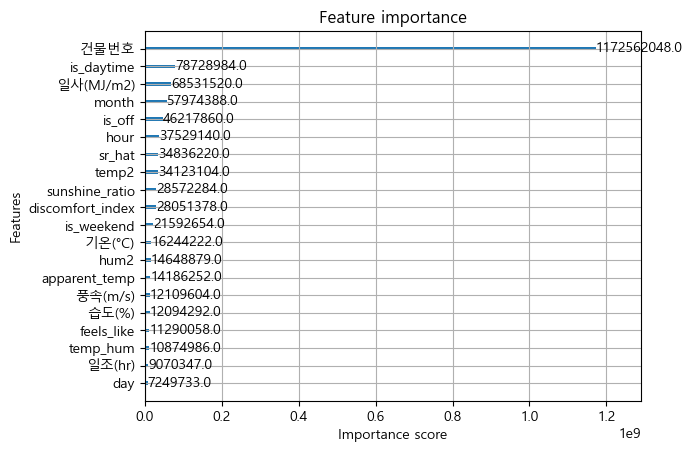

In [ ]:
# 원본 변수에서의 feature importance

from xgboost import plot_importance
import matplotlib.pyplot as plt

# === 원본 변수 버전에서 학습 ===
exclude_cols = ['전력소비량(kWh)', 'log_target', 'date', 'datetime', 
                'num_date_time', 'pred_xgb']
X_train = train_df.drop(columns=exclude_cols, errors='ignore')
y_train = train_df['전력소비량(kWh)']

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

# === 중요도 시각화 ===
plt.figure(figsize=(10,6))
plot_importance(model, max_num_features=20, importance_type="gain")  
plt.show()

# 일사량 : 태양이 실제로 내리쬔 에너지 총량
# 일조 시간 : 햇볕이 비친 시간만 카운트
# 일사량이 더 설명력이 크다고 본 것

In [140]:
# =============================
# 2. sr_hat / ss_hat 생성 (OOF 기반) - 보강 버전
# =============================
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from xgboost import XGBRegressor

def make_oof_feature(df_train, df_test, target_col, new_col, main_target_col="전력소비량(kWh)"):
    """
    df_train/df_test에서 `target_col`을 예측하는 XGBoost 보조모델을 학습해
    OOF 예측값(훈련용)과 Test 예측값을 각각 `new_col`로 추가합니다.
    - 누수 방지: main target, 해당 target_col, 시간키/ID, 타깃 파생/예측치 제외
    - train/test 공통 컬럼만 사용(align)
    """
    if target_col not in df_train.columns:
        print(f"⚠️ {target_col} 컬럼이 없어 {new_col} 생성 생략합니다.")
        return df_train, df_test

    # ✅ 보강된 제외 목록
    exclude_cols = [
        main_target_col,          # '전력소비량(kWh)'
        target_col,               # 지금 예측하는 보조 타깃(일사/일조)
        '건물번호',               # (보수적으로 제외; 필요하면 포함해도 OK)
        'date', 'datetime', '일시',
        'num_date_time', 'answer',
        'log_target', 'pred_xgb'  # 타깃 파생/예측치
    ]

    # 학습에 쓸 공통 피처만 선택
    features = [c for c in df_train.columns if c not in exclude_cols and c in df_test.columns]

    X_train = df_train[features].copy()
    y_train = df_train[target_col].copy()
    X_test  = df_test[features].copy()

    # OOF/Test 예측 초기화
    oof_pred = np.zeros(len(X_train))
    test_pred = np.zeros(len(X_test))

    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    for tr_idx, va_idx in kf.split(X_train):
        X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
        y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]

        model = XGBRegressor(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1
        )
        model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)

        oof_pred[va_idx] = model.predict(X_va)
        test_pred += model.predict(X_test) / kf.n_splits

    # 새 피처 추가
    df_train[new_col] = oof_pred
    df_test[new_col]  = test_pred

    print(f"✅ {new_col} 생성 완료. train shape={df_train.shape}, test shape={df_test.shape}")
    return df_train, df_test


In [141]:
# 2-1. 보조모델 OOF 피처 생성 (함수 셀 '아래' 새 셀에 넣기)
train_df, test_df = make_oof_feature(train_df, test_df, '일사(MJ/m2)', 'sr_hat')
train_df, test_df = make_oof_feature(train_df, test_df, '일조(hr)', 'ss_hat')

✅ sr_hat 생성 완료. train shape=(202666, 32), test shape=(16800, 27)
✅ ss_hat 생성 완료. train shape=(202666, 32), test shape=(16800, 27)


In [ ]:
''' # ============================= #
# 건물별 XGBoost 학습 & OOF / test 예측
# ============================= #
from xgboost import XGBRegressor
from sklearn.model_selection import KFold
import numpy as np

def run_building_xgb(train_df, test_df, target_col='log_target'):
    preds_test = np.zeros(len(test_df))
    preds_oof = np.zeros(len(train_df))

    for b_id in train_df['건물번호'].unique():
        tr_b = train_df[train_df['건물번호'] == b_id].copy()
        te_b = test_df[test_df['건물번호'] == b_id].copy()

        # test_df에 sr_hat/ss_hat 컬럼 없으면 0으로 채움
        for col in ['sr_hat', 'ss_hat']:
            if col not in te_b.columns:
                te_b[col] = 0

        # 학습에 사용할 feature
        features = [c for c in tr_b.columns if c not in ['전력소비량(kWh)', 'log_target', '건물번호', 'date', '일시', '날짜']]
        # test_df에도 있는 컬럼만 사용
        features = [f for f in features if f in te_b.columns]

        X, y = tr_b[features], tr_b[target_col]
        X_test = te_b[features]

        # KFold OOF
        kf = KFold(n_splits=5, shuffle=True, random_state=42)
        oof_pred = np.zeros(len(X))
        test_pred = np.zeros(len(X_test))

        for tr_idx, va_idx in kf.split(X):
            X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
            y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

            model = XGBRegressor(
                n_estimators=1000,
                learning_rate=0.05,
                max_depth=8,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                n_jobs=-1,
                tree_method='hist',  # 속도 개선
                max_bin=256
            )
            model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)

            oof_pred[va_idx] = model.predict(X_va)
            test_pred += model.predict(X_test) / kf.n_splits

        # 결과 저장
        preds_oof[train_df['건물번호'] == b_id] = oof_pred
        preds_test[test_df['건물번호'] == b_id] = test_pred

        print(f"건물 {b_id} OOF 완료")

    # 컬럼 추가
    train_df['pred_xgb'] = preds_oof
    test_df['pred_xgb'] = preds_test
    print("✅ 건물별 XGBoost 예측 완료")

    return train_df, test_df '''"2025.08.11 수업.ipynb"
    # 밑에와 중복, pred_xgb 두번 생김


In [113]:
# ============================= #
# 건물별 + 일사/일조 보조모델 포함 XGBoost 앙상블 (수정)
# ============================= #
from xgboost import XGBRegressor
from sklearn.model_selection import KFold
import numpy as np
import pandas as pd

def run_building_xgb_with_aux(train_df, test_df, target_col='log_target'):
    preds_test = np.zeros(len(test_df))
    preds_oof = np.zeros(len(train_df))

    # log_target 없으면 자동 생성
    if target_col not in train_df.columns:
        train_df = train_df.copy()
        train_df[target_col] = np.log1p(train_df['전력소비량(kWh)'])

    for b_id in train_df['건물번호'].unique():
        tr_b = train_df[train_df['건물번호'] == b_id].copy()
        te_b = test_df[test_df['건물번호'] == b_id].copy()

        # 1) sr_hat / ss_hat 보장
        for col in ['sr_hat', 'ss_hat']:
            if col not in tr_b.columns:
                tr_b[col] = 0
            if col not in te_b.columns:
                te_b[col] = 0

        # 2) 공통 feature 추출 (object/datetime 제외)
        exclude_cols = {
            '전력소비량(kWh)', target_col, '건물번호',
            'date', '일시', '날짜', 'datetime', 'num_date_time'
        }
        features = [c for c in tr_b.columns if c in te_b.columns and c not in exclude_cols]

        # 숫자/불리언만 허용
        features = [c for c in features if pd.api.types.is_numeric_dtype(tr_b[c])]

        X, y = tr_b[features], tr_b[target_col]
        X_test = te_b[features]

        # 3) KFold OOF
        kf = KFold(n_splits=5, shuffle=True, random_state=42)
        oof_pred = np.zeros(len(X))
        test_pred = np.zeros(len(X_test))

        for tr_idx, va_idx in kf.split(X):
            X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
            y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

            model = XGBRegressor(
                n_estimators=1000,
                learning_rate=0.05,
                max_depth=8,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                n_jobs=-1,
                tree_method='hist'
            )
            model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)

            oof_pred[va_idx] = model.predict(X_va)
            test_pred += model.predict(X_test) / kf.n_splits

        preds_oof[train_df['건물번호'] == b_id] = oof_pred
        preds_test[test_df['건물번호'] == b_id] = test_pred

        print(f"✅ 건물 {b_id} OOF 완료 (features={len(features)})")

    # log 복원
    train_df = train_df.copy()
    test_df  = test_df.copy()
    train_df['pred_xgb'] = np.expm1(preds_oof)
    test_df['pred_xgb']  = np.expm1(preds_test)

    def smape(y_true, y_pred):
        denom = (np.abs(y_true) + np.abs(y_pred)) / 2
        diff = np.abs(y_true - y_pred) / np.where(denom == 0, 1, denom)
        return np.mean(diff) * 100

    s = smape(train_df['전력소비량(kWh)'], train_df['pred_xgb'])
    print(f"[AUX + BUILDING] OOF SMAPE: {s:.3f}%")

    return train_df, test_df

# ============================= #
# 실행
# ============================= #
train_df, test_df = run_building_xgb_with_aux(train_df, test_df)

✅ 건물 1 OOF 완료 (features=20)
✅ 건물 2 OOF 완료 (features=20)
✅ 건물 3 OOF 완료 (features=20)
✅ 건물 4 OOF 완료 (features=20)
✅ 건물 5 OOF 완료 (features=20)
✅ 건물 6 OOF 완료 (features=20)
✅ 건물 7 OOF 완료 (features=20)
✅ 건물 8 OOF 완료 (features=20)
✅ 건물 9 OOF 완료 (features=20)
✅ 건물 10 OOF 완료 (features=20)
✅ 건물 11 OOF 완료 (features=20)
✅ 건물 12 OOF 완료 (features=20)
✅ 건물 13 OOF 완료 (features=20)
✅ 건물 14 OOF 완료 (features=20)
✅ 건물 15 OOF 완료 (features=20)
✅ 건물 16 OOF 완료 (features=20)
✅ 건물 17 OOF 완료 (features=20)
✅ 건물 18 OOF 완료 (features=20)
✅ 건물 19 OOF 완료 (features=20)
✅ 건물 20 OOF 완료 (features=20)
✅ 건물 21 OOF 완료 (features=20)
✅ 건물 22 OOF 완료 (features=20)
✅ 건물 23 OOF 완료 (features=20)
✅ 건물 24 OOF 완료 (features=20)
✅ 건물 25 OOF 완료 (features=20)
✅ 건물 26 OOF 완료 (features=20)
✅ 건물 27 OOF 완료 (features=20)
✅ 건물 28 OOF 완료 (features=20)
✅ 건물 29 OOF 완료 (features=20)
✅ 건물 30 OOF 완료 (features=20)
✅ 건물 31 OOF 완료 (features=20)
✅ 건물 32 OOF 완료 (features=20)
✅ 건물 33 OOF 완료 (features=20)
✅ 건물 34 OOF 완료 (features=20)
✅ 건물 35 OOF 완료 (feature

In [116]:
import numpy as np
from xgboost import XGBRegressor

# ===== 학습용 데이터 준비 (ID/시간 컬럼 제거) =====
exclude_cols = ['전력소비량(kWh)', 'log_target', 'pred_xgb', 
                'date', 'datetime', 'num_date_time']
X_train = train_df.drop(columns=exclude_cols, errors='ignore').copy()
X_test  = test_df.drop(columns=exclude_cols, errors='ignore').copy()
y_train = train_df['전력소비량(kWh)']

# 건물번호를 category로 변환
if '건물번호' in X_train.columns:
    X_train['건물번호'] = X_train['건물번호'].astype('category')
    X_test['건물번호']  = X_test['건물번호'].astype('category')

# ===== log transform 적용 =====
y_train_log = np.log1p(y_train)

# ===== 모델 정의 =====
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    enable_categorical=True  # ✅ 카테고리 지원
)

# ===== 학습 =====
model.fit(X_train, y_train_log)

# ===== 학습 데이터 예측 (log 복원) =====
y_pred_train = np.expm1(model.predict(X_train))

# ===== SMAPE 계산 =====
def smape(y_true, y_pred):
    return 100/len(y_true) * np.sum(
        2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-9)
    )

print("Current SMAPE:", smape(y_train, y_pred_train))

Current SMAPE: 4.477513583853441


In [142]:
from sklearn.model_selection import KFold
import pandas as pd
import numpy as np
from xgboost import XGBRegressor

# === 보조 피처 생성 (컬럼명 확인 후 수정 필요) ===
X_train2, X_test2 = X_train.copy(), X_test.copy()
X_train2, X_test2 = make_oof_feature(X_train2, X_test2, '일사(MJ/m2)', 'sr_hat')
X_train2, X_test2 = make_oof_feature(X_train2, X_test2, '일조(hr)',     'ss_hat')

✅ sr_hat 생성 완료. train shape=(202666, 23), test shape=(16800, 20)
✅ ss_hat 생성 완료. train shape=(202666, 23), test shape=(16800, 20)


In [118]:
# =============================
# 2) 글로벌 메인 모델 (train/test 공통 feature만 사용)
# =============================

# train/test 공통 feature만 추출
common_cols = [c for c in X_train2.columns if c in X_test2.columns and c != 'answer']
Xm_train = X_train2[common_cols]
Xm_test  = X_test2[common_cols]

kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_main = np.zeros(len(Xm_train))
pred_test_main = np.zeros(len(Xm_test))

params_main = dict(
    n_estimators=800, learning_rate=0.05, max_depth=8,
    subsample=0.8, colsample_bytree=0.8, random_state=42,
    n_jobs=-1, enable_categorical=True
)

for tr_idx, va_idx in kf.split(Xm_train):
    Xtr, Xva = Xm_train.iloc[tr_idx], Xm_train.iloc[va_idx]
    ytr, yva = y_train.iloc[tr_idx], y_train.iloc[va_idx]

    ytr_log = np.log1p(ytr)

    m = XGBRegressor(**params_main)
    m.fit(Xtr, ytr_log)
    oof_main[va_idx] = np.expm1(m.predict(Xva))
    pred_test_main += np.expm1(m.predict(Xm_test)) / kf.n_splits

print(f"[GLOBAL+SR/SS] OOF SMAPE: {smape(y_train, oof_main):.3f}%")



[GLOBAL+SR/SS] OOF SMAPE: 4.831%


In [119]:
# =============================
# 3) 건물별 모델 (최적화 버전)
# =============================

pred_test_building = np.zeros(len(X_test2))
oof_building = np.zeros(len(X_train2))

unique_blds = X_train2['건물번호'].unique()

params_bld = dict(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    subsample=0.85, colsample_bytree=0.85, random_state=42,
    n_jobs=-1, enable_categorical=True
)

for b in unique_blds:
    tr_mask = (X_train2['건물번호'] == b)
    te_mask = (X_test2['건물번호'] == b)

    Xb_tr = X_train2[tr_mask]
    yb_tr = y_train[tr_mask]
    Xb_te = X_test2[te_mask]

    # 🔑 데이터가 적으면 건너뛰기 (글로벌 예측 사용)
    if len(Xb_tr) < 100:
        if te_mask.sum() > 0:
            pred_test_building[te_mask] = pred_test_main[te_mask]
        continue

    # train/test 공통 feature만 사용 (+안전: datetime/num_date_time 제외)
    common_cols = [c for c in Xb_tr.columns 
        if c in Xb_te.columns and c not in ['answer', 'datetime', 'num_date_time']]
    Xb_tr = Xb_tr[common_cols]
    Xb_te = Xb_te[common_cols]

    print(f"건물 {b} 사용 피처 수: {len(common_cols)}")  # ✅ 디버깅용


    # Hold-out 검증 (5-Fold 대신 1회 split)
    from sklearn.model_selection import train_test_split
    Xtr, Xva, ytr, yva = train_test_split(Xb_tr, yb_tr, test_size=0.2, random_state=42)
    ytr_log = np.log1p(ytr)

    mb = XGBRegressor(**params_bld)
    mb.fit(Xtr, ytr_log)

    # OOF & Test 예측
    oof_building[tr_mask] = np.expm1(mb.predict(Xb_tr))
    if len(Xb_te) > 0:
        pred_test_building[te_mask] = np.expm1(mb.predict(Xb_te))

print(f"[BUILDING-FAST] OOF SMAPE: {smape(y_train, oof_building):.3f}%")


건물 1 사용 피처 수: 20
건물 2 사용 피처 수: 20
건물 3 사용 피처 수: 20
건물 4 사용 피처 수: 20
건물 5 사용 피처 수: 20
건물 6 사용 피처 수: 20
건물 7 사용 피처 수: 20
건물 8 사용 피처 수: 20
건물 9 사용 피처 수: 20
건물 10 사용 피처 수: 20
건물 11 사용 피처 수: 20
건물 12 사용 피처 수: 20
건물 13 사용 피처 수: 20
건물 14 사용 피처 수: 20
건물 15 사용 피처 수: 20
건물 16 사용 피처 수: 20
건물 17 사용 피처 수: 20
건물 18 사용 피처 수: 20
건물 19 사용 피처 수: 20
건물 20 사용 피처 수: 20
건물 21 사용 피처 수: 20
건물 22 사용 피처 수: 20
건물 23 사용 피처 수: 20
건물 24 사용 피처 수: 20
건물 25 사용 피처 수: 20
건물 26 사용 피처 수: 20
건물 27 사용 피처 수: 20
건물 28 사용 피처 수: 20
건물 29 사용 피처 수: 20
건물 30 사용 피처 수: 20
건물 31 사용 피처 수: 20
건물 32 사용 피처 수: 20
건물 33 사용 피처 수: 20
건물 34 사용 피처 수: 20
건물 35 사용 피처 수: 20
건물 36 사용 피처 수: 20
건물 37 사용 피처 수: 20
건물 38 사용 피처 수: 20
건물 39 사용 피처 수: 20
건물 40 사용 피처 수: 20
건물 41 사용 피처 수: 20
건물 42 사용 피처 수: 20
건물 43 사용 피처 수: 20
건물 44 사용 피처 수: 20
건물 45 사용 피처 수: 20
건물 46 사용 피처 수: 20
건물 47 사용 피처 수: 20
건물 48 사용 피처 수: 20
건물 49 사용 피처 수: 20
건물 50 사용 피처 수: 20
건물 51 사용 피처 수: 20
건물 52 사용 피처 수: 20
건물 53 사용 피처 수: 20
건물 54 사용 피처 수: 20
건물 55 사용 피처 수: 20
건물 56 사용 피처 수: 20
건

In [120]:
# =============================
# 4) 글로벌 + 건물별 앙상블
# =============================

w_building, w_global = 0.6, 0.4  # 가중치 (조정 가능)

oof_blend  = w_building * oof_building + w_global * oof_main
test_blend = w_building * pred_test_building + w_global * pred_test_main

print(f"[BLEND] OOF SMAPE: {smape(y_train, oof_blend):.3f}%")

# =============================
# 제출 파일 생성
# =============================

# 원본 test 불러오기 (한번만 선언하면 됨)
test_raw = pd.read_csv("test.csv")

sub = pd.DataFrame({
    'num_date_time': test_raw['num_date_time'].values,  # 원본 test에서 ID 가져오기
    'answer': test_blend                                # 최종 앙상블 예측값
})

save_path = 'submission_xgb_blend.csv'
sub.to_csv(save_path, index=False, encoding='utf-8-sig')

print(f"✅ 제출 파일 저장 완료: {save_path}")
print(sub.head())



[BLEND] OOF SMAPE: 2.700%
✅ 제출 파일 저장 완료: submission_xgb_blend.csv
   num_date_time       answer
0  1_20240825 00  4208.387305
1  1_20240825 01  4093.516821
2  1_20240825 02  3680.789722
3  1_20240825 03  3380.135229
4  1_20240825 04  3363.521265


In [125]:
# ================================
# 가중치 최적화 (Blending)
# ================================
import numpy as np

def smape(y_true, y_pred):
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-9))

# 후보 weight 탐색 (0 ~ 1, step=0.05)
best_score = 1e9
best_w = None

for w in np.linspace(0, 1, 21):  # 0, 0.05, ..., 1.0
    oof_blend = w * oof_main + (1-w) * oof_building   # ✅ 수정
    score = smape(y_train, oof_blend)
    if score < best_score:
        best_score = score
        best_w = w

print(f"✅ Best Weight: {best_w:.2f}, OOF SMAPE: {best_score:.4f}%")

# ================================
# 최적 weight로 Test 예측 생성
# ================================
test_blend = best_w * pred_test_main + (1-best_w) * pred_test_building   # ✅ 수정

# 제출 파일 생성
test_raw = pd.read_csv("test.csv")   # 원본에서 ID 불러오기

sub = pd.DataFrame({
    'num_date_time': test_raw['num_date_time'].values,  # 식별자
    'answer': test_blend
})

save_path = 'submission_blend_opt.csv'
sub.to_csv(save_path, index=False, encoding='utf-8-sig')

print(f"✅ 제출 파일 저장 완료: {save_path}")
print(sub.head())


✅ Best Weight: 0.00, OOF SMAPE: 1.5650%
✅ 제출 파일 저장 완료: submission_blend_opt.csv
   num_date_time       answer
0  1_20240825 00  4338.912109
1  1_20240825 01  4240.679199
2  1_20240825 02  3720.350098
3  1_20240825 03  3363.182373
4  1_20240825 04  3348.775635


In [122]:
# train_df / test_df 안에 sr_hat, ss_hat 컬럼이 존재하는지 확인
print("train_df columns:", [c for c in train_df.columns if 'sr' in c or 'ss' in c])
print("test_df columns:", [c for c in test_df.columns if 'sr' in c or 'ss' in c])

# 혹시 값까지 확인하고 싶으면
print(train_df[['sr_hat', 'ss_hat']].head())
print(test_df[['sr_hat', 'ss_hat']].head())


train_df columns: ['sr_hat', 'ss_hat']
test_df columns: ['sr_hat', 'ss_hat']
     sr_hat    ss_hat
0 -0.005059 -0.006324
1 -0.018958 -0.006636
2 -0.031480 -0.011246
3 -0.008502 -0.011459
4 -0.008467 -0.005061
     sr_hat    ss_hat
0 -0.024921  0.003643
1 -0.022527  0.002106
2 -0.015072  0.001441
3 -0.017756  0.000703
4 -0.015887  0.000557


현재의 문제점 

내부 OOF SMAPE: 1.56% → 굉장히 낮음 (모델은 train/val에서 잘 맞춘다)
리더보드 점수: 6.7 → GAP이 큼 (과적합 or generalization 문제)

즉, 모델이 train 데이터 패턴에 너무 맞춰져 있고, test 데이터(리더보드 분포)에서는 성능이 떨어지는 상황이에요.

✅ 점수 개선을 위해 고려할 수 있는 방향
# 시간적 분포 차이(Timestamp leakage) 확인
Train 데이터는 6월8월, Test는 8월 말9월 이런 식으로 시계열 분포가 다를 수 있음.
KFold 대신 TimeSeriesSplit 또는 월 단위 validation split을 써서 “미래 예측” 환경을 반영해야 과적합 줄일 수 있어요.

# Feature Distribution Drift 확인
기온, 습도, 일사량 같은 기상 데이터가 train/test에서 다른 분포를 가지는지 체크.
만약 drift가 크다면, 표준화(normalization)나 도메인 적응(feature scaling by month/season) 필요.

# 파생변수 개선
이미 시간/휴일을 넣었으니 →
연속 공휴일 플래그 (앞/뒤 하루 포함)
날짜 순서 (순차 index: 0,1,2,..) → 시계열 trend 반영
lag features (전날/전주 같은 시점의 전력소비량, rolling mean 등)
단, 과적합 위험 있으니 LightGBM/XGBoost early_stop 잘 걸어야 함.

# 앙상블 개선
지금은 global vs building (0.6:0.4) 고정 →
Building별 최적 가중치 다르게 두기
LightGBM, CatBoost 같은 다른 계열 모델 섞기
Stacking (2nd-level meta model) 시도
Evaluation Metric 대응
SMAPE는 작은 값일수록 오차 영향이 커짐 → log transform은 이미 했지만,
target scaling (예: 전력 사용량이 큰 건물은 상대적 비중을 낮추는 방식) 도 고려 가능.

In [ ]:
# 8/18일 수업 전까지 점수 개선을 한가지 더 해보기 (6.5안에 들어야 100등)